# 3W Dataset: Domain Distance Analysis

We construct our 3 Source-Target domain pairs from the 3W dataset and compute
the quantitative distance between them, then measure how well a Random Forest
transfers across each pair.

## Setup and data loading

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import scipy.linalg

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wasserstein_distance

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

EXTRACTED_DATA_DIR = os.path.join(
    PROJECT_ROOT, 'data',
    'Data for A Realistic and Public Dataset with Rare Undesirable Real Events in Oil Wells',
    'data'
)

CLASS_NAMES = {
    0: 'Normal',
    1: 'Abrupt Increase of BSW',
    2: 'Spurious Closure of DHSV',
    3: 'Severe Slugging',
    4: 'Flow Instability',
    5: 'Rapid Productivity Loss',
    6: 'Quick Restriction in PCK',
    7: 'Scaling in PCK',
    8: 'Hydrate in Production Line',
}
VARIABLE_NAMES = ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP',
                  'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL']
SOURCES = ['real', 'simulated', 'handdrawn']

In [3]:
def detect_source(filename: str) -> str:
    name = os.path.splitext(filename)[0]
    if name.startswith('DRAWN'): return 'handdrawn'
    if name.startswith('SIMULATED'): return 'simulated'
    if name.startswith('WELL'): return 'real'
    return 'unknown'

def load_all_instances(data_dir: str, class_names: dict) -> dict:
    all_instances = {}
    for class_code in class_names:
        class_dir = os.path.join(data_dir, str(class_code))
        if not os.path.isdir(class_dir):
            continue
        csv_files = sorted(glob.glob(os.path.join(class_dir, '*.csv')))
        if not csv_files:
            continue
        class_instances = {}
        for fpath in csv_files:
            fname = os.path.basename(fpath)
            source = detect_source(fname)
            df = pd.read_csv(fpath)
            if 'timestamp' in df.columns:
                df['timestamp'] = pd.to_datetime(df['timestamp'])
            instance_id = os.path.splitext(fname)[0]
            if source not in class_instances:
                class_instances[source] = []
            class_instances[source].append({
                'id': instance_id, 'path': fpath, 'data': df,
                'n_vars': len([c for c in df.columns if c not in ('timestamp', 'class')]),
                'n_obs': df.shape[0],
            })
        if class_instances:
            all_instances[class_code] = class_instances
    return all_instances

data = load_all_instances(EXTRACTED_DATA_DIR, CLASS_NAMES)

total = sum(sum(len(lst) for lst in src_dict.values()) for src_dict in data.values())
print(f'Loaded {total} instances across {len(data)} classes.')

Loaded 1984 instances across 9 classes.


## Domain Pairs:

*   **Different Sources (Simulated vs Real):** Instances generated by the
    OLGA multiphase flow simulator (Source) vs. real wells (Target), over the
    6 event classes shared by both sources (1, 2, 3, 5, 6, 8).
*   **Different Wells (Components):** Instances from wells 1+2 (Source) vs.
    wells 5+10 (Target), over classes 0 (Normal) and 4 (Flow Instability).
*   **Different Time Periods:** Instances from well 2 recorded in 2013
    (Source) vs. 2014+2017 (Target), over classes 0 and 4.

In [4]:
def extract_features(data: dict, source: str, classes: list) -> tuple:
    """
    Extract 7 statistical features per variable (56 total) per instance.

    Args:
        data (dict): The dataset dictionary.
        source (str): The source key to extract from.
        classes (list): Class codes to include.
    Returns:
        tuple: (X, y, instance_ids)
    """
    features = []
    labels = []
    instance_ids = []

    for cls in classes:
        if cls not in data or source not in data[cls]:
            continue
        for inst in data[cls][source]:
            df = inst['data']
            feats = []
            for var in VARIABLE_NAMES:
                if var in df.columns:
                    vals = df[var].values
                    feats.extend([
                        np.nanmean(vals),
                        np.nanstd(vals),
                        np.nanmin(vals),
                        np.nanpercentile(vals, 25),
                        np.nanpercentile(vals, 50),
                        np.nanpercentile(vals, 75),
                        np.nanmax(vals),
                    ])
                else:
                    feats.extend([np.nan] * 7)
            features.append(feats)
            labels.append(cls)
            instance_ids.append(inst['id'])

    X = np.array(features, dtype=np.float64)
    y = np.array(labels)

    # nan values are replaced with column medians (or 0 if entire column is NaN)
    col_medians = np.nanmedian(X, axis=0)
    nan_mask = np.isnan(X)
    for j in range(X.shape[1]):
        if np.isnan(col_medians[j]):
            col_medians[j] = 0.0
        X[nan_mask[:, j], j] = col_medians[j]

    # replace inf values with column max/min (or 1/-1 if entire column is inf)
    for j in range(X.shape[1]):
        col = X[:, j]
        finite_vals = col[np.isfinite(col)]
        if len(finite_vals) > 0:
            col_max = np.max(finite_vals)
            col_min = np.min(finite_vals)
        else:
            col_max, col_min = 1.0, -1.0
        col[~np.isfinite(col) & (col > 0)] = col_max
        col[~np.isfinite(col) & (col < 0)] = col_min
        X[:, j] = np.clip(col, -1e15, 1e15)

    return X, y, instance_ids

stat_names = ['mean', 'std', 'min', 'p25', 'p50', 'p75', 'max']
feature_names = [f'{var}_{stat}' for var in VARIABLE_NAMES for stat in stat_names]
print(f'Feature vector: {len(feature_names)} dimensions')

Feature vector: 56 dimensions


In [5]:
def to_pair_df(X: np.ndarray, y: np.ndarray, ids: list) -> pd.DataFrame:
    """
    Convert feature matrix, labels, and instance IDs into a DataFrame.

    Args:
        X (np.ndarray): Feature matrix.
        y (np.ndarray): Class labels.
        ids (list): List of instance IDs.
    Returns:
        pd.DataFrame: DataFrame containing features, class labels, and instance IDs.
    """
    df = pd.DataFrame(X, columns=feature_names)
    df['Class'] = y
    df['id'] = ids
    return df

# Pair 1: Different Sources (Simulated -> Real): classes 1,2,3,5,6,8
SRC_CLASSES = [1, 2, 3, 5, 6, 8]
X_sim, y_sim, id_sim = extract_features(data, 'simulated', SRC_CLASSES)
X_real, y_real, id_real = extract_features(data, 'real', SRC_CLASSES)
source_sim = to_pair_df(X_sim, y_sim, id_sim)
target_real = to_pair_df(X_real, y_real, id_real)
print('Different Sources (Simulated -> Real): classes 1,2,3,5,6,8')
print(f'Source (Simulated): {len(source_sim)} instances over {len(np.unique(y_sim))} classes')
print(f'Target (Real): {len(target_real)} instances over {len(np.unique(y_real))} classes')

# Pair 2: Different Wells (wells 1+2 -> 5+10): classes 0 and 4
def get_well_id(inst_id: str) -> str | None:
    """
    Extract the well ID from an instance ID.

    Args:
        inst_id (str): Instance ID.

    Returns:
        str | None: Well ID if found, otherwise None.
    """
    if inst_id.startswith('WELL'):
        return inst_id.split('_')[0]
    return None

well_src = ['WELL-00001', 'WELL-00002']
well_tgt = ['WELL-00005', 'WELL-00010']
data_well = {}
for cls in [0, 4]:
    data_well[cls] = {}
    data_well[cls]['src'] = [i for i in data[cls].get('real', []) if get_well_id(i['id']) in well_src]
    data_well[cls]['tgt'] = [i for i in data[cls].get('real', []) if get_well_id(i['id']) in well_tgt]

X_w_src, y_w_src, id_w_src = extract_features(data_well, 'src', [0, 4])
X_w_tgt, y_w_tgt, id_w_tgt = extract_features(data_well, 'tgt', [0, 4])
source_wells = to_pair_df(X_w_src, y_w_src, id_w_src)
target_wells = to_pair_df(X_w_tgt, y_w_tgt, id_w_tgt)
print('Different Wells (Wells 1+2 -> 5+10): classes 0 and 4')
print(f'Source (Wells 1+2): {len(source_wells)} instances over classes 0 and 4')
print(f'Target (Wells 5+10): {len(target_wells)} instances over classes 0 and 4')

# Pair 3: Different Time Periods (well 2, 2013 -> 2014+2017): classes 0 and 4
def get_year(inst_id: str) -> int | None:
    """
    Extract the year from an instance ID.

    Args:
        inst_id (str): Instance ID.

    Returns:
        int | None: Year if found, otherwise None.
    """
    parts = inst_id.split('_')
    if len(parts) >= 2 and parts[0].startswith('WELL'):
        ts = parts[-1]
        if len(ts) >= 8 and ts.isdigit():
            return int(ts[:4])
    return None

data_time = {}
for cls in [0, 4]:
    data_time[cls] = {}
    data_time[cls]['src'] = []
    data_time[cls]['tgt'] = []
    for inst in data[cls].get('real', []):
        if get_well_id(inst['id']) == 'WELL-00002':
            y = get_year(inst['id'])
            if y == 2013:
                data_time[cls]['src'].append(inst)
            if y in (2014, 2017):
                data_time[cls]['tgt'].append(inst)

X_t_src, y_t_src, id_t_src = extract_features(data_time, 'src', [0, 4])
X_t_tgt, y_t_tgt, id_t_tgt = extract_features(data_time, 'tgt', [0, 4])
source_time = to_pair_df(X_t_src, y_t_src, id_t_src)
target_time = to_pair_df(X_t_tgt, y_t_tgt, id_t_tgt)
print('Different Time Periods (well 2, 2013 -> 2014+2017): classes 0 and 4')
print(f'Source (2013): {len(source_time)} instances over classes 0 and 4')
print(f'Target (2014+17): {len(target_time)} instances over classes 0 and 4')

Different Sources (Simulated -> Real): classes 1,2,3,5,6,8
Source (Simulated): 939 instances over 6 classes
Target (Real): 80 instances over 6 classes


Different Wells (Wells 1+2 -> 5+10): classes 0 and 4
Source (Wells 1+2): 453 instances over classes 0 and 4
Target (Wells 5+10): 202 instances over classes 0 and 4


Different Time Periods (well 2, 2013 -> 2014+2017): classes 0 and 4
Source (2013): 31 instances over classes 0 and 4
Target (2014+17): 292 instances over classes 0 and 4


## Global vs. Conditional Shift:

Across all three domain pairs, class 0 (Normal) is the majority of the real
data. The task for this dataset is to detect and classify the undesirable
events, so pooled distances would be dominated by the 'Normal' instances and
blind to how much the event classes themselves shift. We therefore isolate
the **conditional shift** of the event classes used by each pair's transfer
experiment.

Before we compute the mathematical distances, let's visually verify if the
Global Shift differs from the Conditional Shift (Event Classes Only).

In [6]:
def explore_domains_pca(source_df: pd.DataFrame, target_df: pd.DataFrame, source_name: str, target_name: str,
                        features: list, conditional_classes: list):
    """
    Performs Global and Conditional PCA to visualize Covariate Shift vs
    Concept Drift for a source-target pair.

    Args:
        source_df (pd.DataFrame): Source domain DataFrame.
        target_df (pd.DataFrame): Target domain DataFrame.
        source_name (str): Name of the source domain.
        target_name (str): Name of the target domain.
        features (list): List of feature column names to use for PCA.
        conditional_classes (list): List of class labels to filter for Conditional PCA.
    """
    src_sample = source_df.copy()
    tgt_sample = target_df.copy()
    src_sample['Domain'] = source_name
    tgt_sample['Domain'] = target_name
    combined_df = pd.concat([src_sample, tgt_sample])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(combined_df[features])

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_scaled)
    combined_df['PCA1'] = pca_result[:, 0]
    combined_df['PCA2'] = pca_result[:, 1]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Global PCA
    sns.scatterplot(
        x='PCA1', y='PCA2', hue='Domain', data=combined_df,
        alpha=0.3, s=15, ax=axes[0], palette=['#1f77b4', '#ff7f0e']
    )
    axes[0].set_title(f'Global PCA: {source_name} vs {target_name}\n(Covariate Shift)',
                      fontweight='bold', fontsize=14)

    # Plot 2: Conditional PCA (Event Classes Only)
    cond = combined_df[combined_df['Class'].isin(conditional_classes)]
    if len(cond) > 0:
        X_cond = scaler.transform(cond[features])
        pca_cond = pca.transform(X_cond)
        cond = cond.copy()
        cond['PCA1'] = pca_cond[:, 0]
        cond['PCA2'] = pca_cond[:, 1]
        sns.scatterplot(
            x='PCA1', y='PCA2', hue='Domain', data=cond,
            alpha=0.6, s=30, ax=axes[1], palette=['#1f77b4', '#ff7f0e']
        )
        axes[1].set_title(f'Conditional PCA (Event Classes Only)\n(Concept Drift)',
                          fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.show()

Different sources (Simulated vs Real)


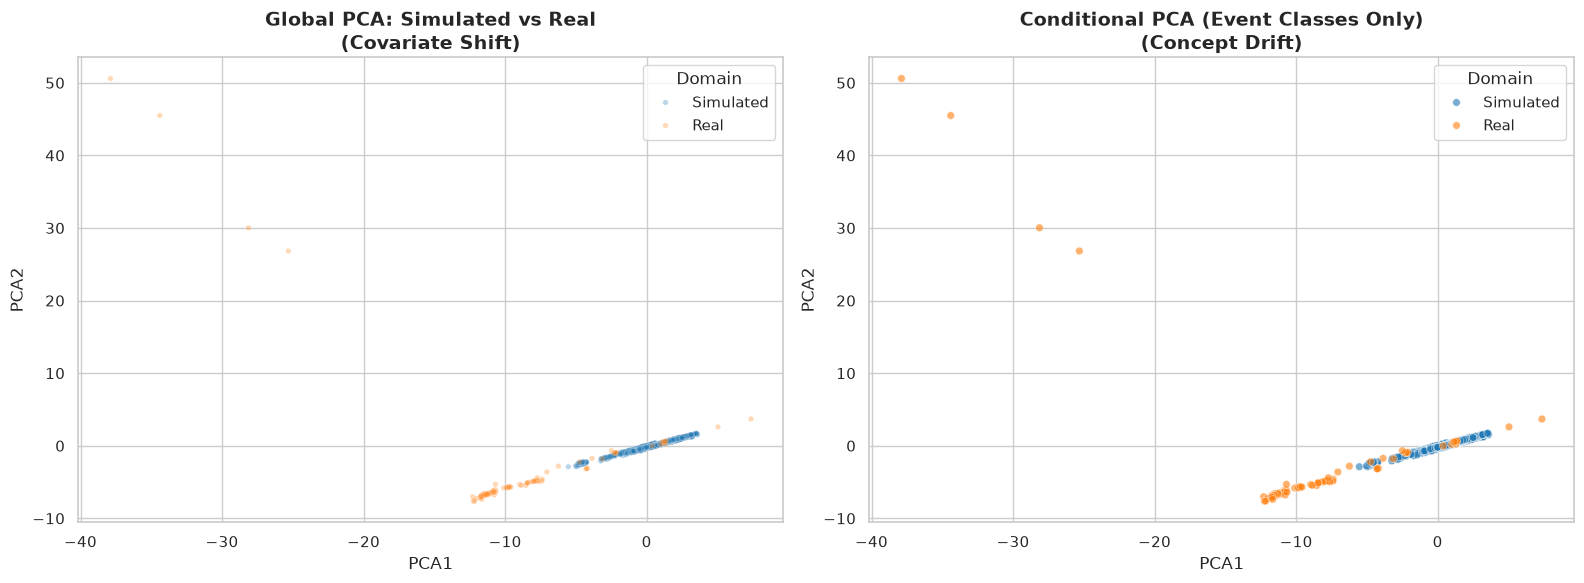

In [7]:
print("Different sources (Simulated vs Real)")
explore_domains_pca(source_sim, target_real, 'Simulated', 'Real',
                    feature_names, conditional_classes=SRC_CLASSES)


Exploring different wells


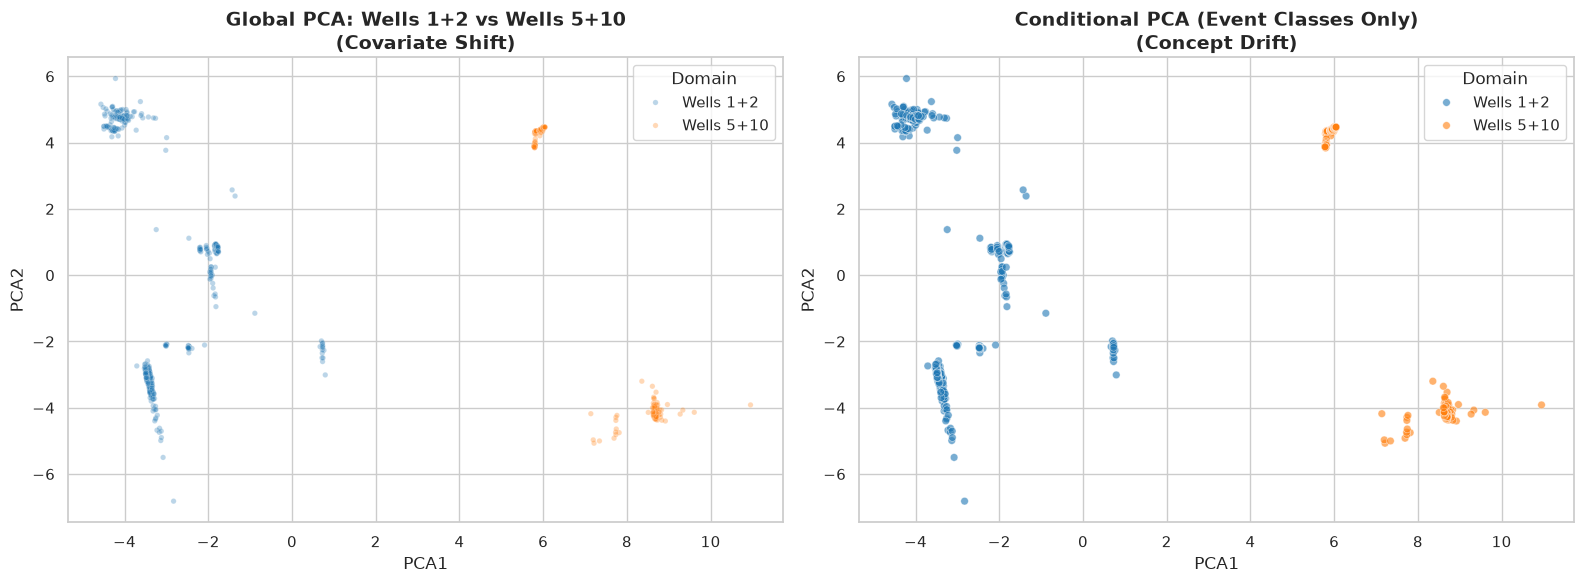

In [8]:
print("\nExploring different wells")
explore_domains_pca(source_wells, target_wells, 'Wells 1+2', 'Wells 5+10',
                    feature_names, conditional_classes=[0, 4])


Exploring different time periods


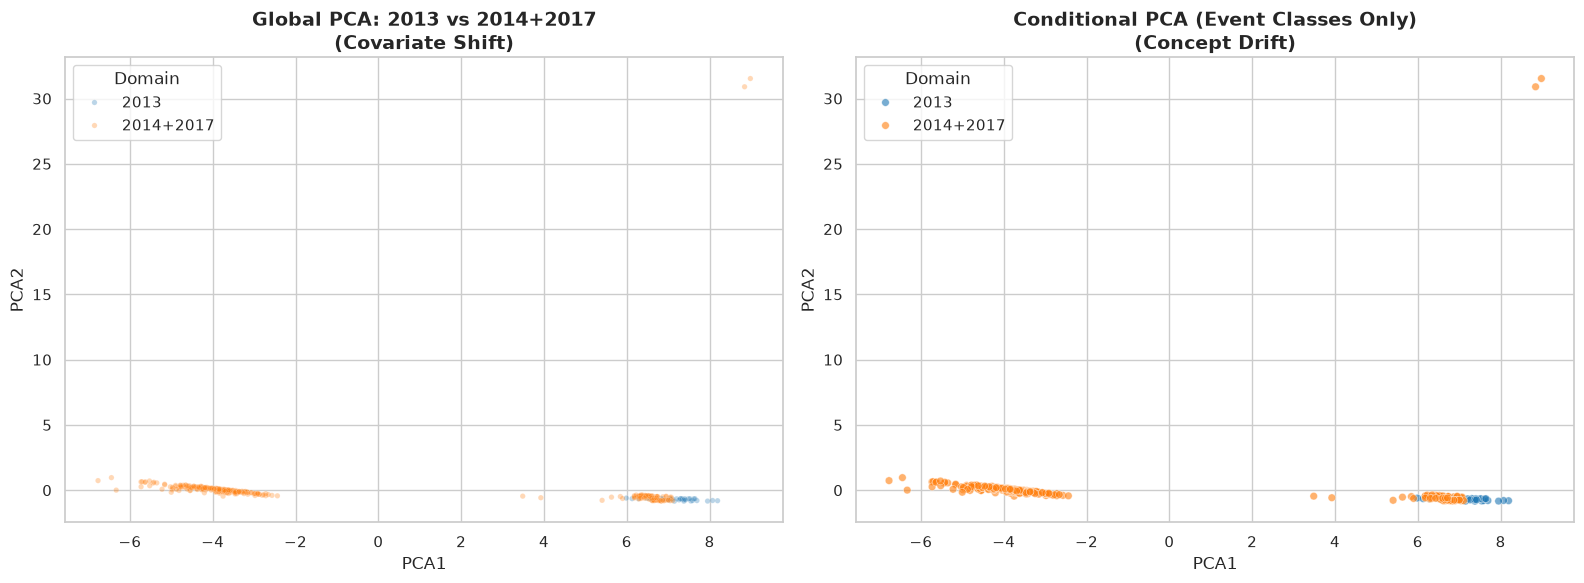

In [9]:
print("\nExploring different time periods")
explore_domains_pca(source_time, target_time, '2013', '2014+2017',
                    feature_names, conditional_classes=[0, 4])

The PCA plots show that the event classes shift between domains, and because
our classification task relies entirely on those classes, global distances
would be dominated by the majority class and misrank the domain gaps. We
therefore compute **Conditional Distances (Event Classes Only)**: per-class
distances averaged over the classes used by each pair's transfer experiment.

## Distance Metrics

Having defined and explored our domains, we now compute three mathematically
diverse distance metrics to strictly quantify the **Conditional Domain Shift**
between the event classes of our sources and targets. We will use the
following metrics:

- **Sliced Wasserstein Distance (SWD)**: Measures the distance between two
  probability distributions by projecting them onto one-dimensional
  subspaces. It efficiently captures the overall difference in the spatial
  multivariate shape of the event classes.
- **Maximum Mean Discrepancy (MMD)**: Measures the distance between two
  probability distributions by comparing their means in a reproducing kernel
  Hilbert space (RBF kernel). It is highly effective at capturing complex,
  non-linear spatial shifts between the class clusters.
- **Fréchet Distance (FD)**: Computes the mathematical distance between two
  multivariate Gaussians fitted directly to our feature space. By heavily
  weighting the geometric distance between the cluster means alongside their
  covariance, it provides a robust, linear measure of how the class
  distributions migrate across domains.

In [10]:
def sliced_wasserstein(X: np.ndarray, Y: np.ndarray, n_projections: int = 50, random_state: int = 42) -> float:
    """
    Sliced Wasserstein Distance: mean 1D Wasserstein over random projections.
    
    Args:
        X (np.ndarray): Source domain feature matrix.
        Y (np.ndarray): Target domain feature matrix.
        n_projections (int): Number of random projections to use.
        random_state (int): Random state for reproducibility.
    Returns:
        float: The mean Sliced Wasserstein Distance between X and Y.
    """
    rng = np.random.default_rng(random_state)
    d = X.shape[1]
    projections = rng.standard_normal((n_projections, d))
    projections /= np.linalg.norm(projections, axis=1, keepdims=True)
    dists = []
    for p in projections:
        dists.append(wasserstein_distance(X @ p, Y @ p))
    return np.mean(dists)

def mmd_rbf(X: np.ndarray, Y: np.ndarray, gamma: float = 0.1) -> float:
    """
    Maximum Mean Discrepancy using an RBF kernel.
    
    Args:
        X (np.ndarray): Source domain feature matrix.
        Y (np.ndarray): Target domain feature matrix.
        gamma (float): Parameter for the RBF kernel.
    Returns:
        float: The Maximum Mean Discrepancy between X and Y.
    """
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

def frechet_distance(X: np.ndarray, Y: np.ndarray, eps: float = 1e-3) -> float:
    """
    Fréchet Distance between two multivariate Gaussians fitted to the data.

    NOTE: eps is used to regularize the covariance matrices, indeed the class 
    subsets are small (5-30 instances in 56 dimensions), so unregularized 
    covariances are singular and scipy.linalg.sqrtm becomes numerically unstable.

    Args:
        X (np.ndarray): Source domain feature matrix.
        Y (np.ndarray): Target domain feature matrix.
        eps (float): Regularization term for covariance matrices.
    Returns:
        float: The Fréchet Distance between the distributions of X and Y.
    """
    mu1, sigma1 = X.mean(axis=0), np.cov(X, rowvar=False) + eps * np.eye(X.shape[1])
    mu2, sigma2 = Y.mean(axis=0), np.cov(Y, rowvar=False) + eps * np.eye(X.shape[1])

    diff = mu1 - mu2

    covmean = scipy.linalg.sqrtm(sigma1.dot(sigma2))
    covmean = np.real(covmean)  # sqrtm can leave tiny imaginary parts

    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)

def compute_conditional_distances(source_df: pd.DataFrame, target_df: pd.DataFrame, features: list, class_code: int, min_instances: int = 5):
    """
    Conditional distance for a single class: filters the pair to that class,
    standardizes with a source-fitted scaler, and computes SWD, MMD, FD.
    Returns None when either side has fewer than min_instances instances
    (covariance-based FD is not meaningful on 1-4 samples).

    Args:
        source_df (pd.DataFrame): Source domain DataFrame.
        target_df (pd.DataFrame): Target domain DataFrame.
        features (list): List of feature column names to use for distance computation.
        class_code (int): The class label to filter on.
        min_instances (int): Minimum number of instances required on both sides to compute distances.
    Returns:
        dict | None: Dictionary containing SWD, MMD, FD, n_src, n_tgt if distances are computed, otherwise None.
    """
    src = source_df[source_df['Class'] == class_code]
    tgt = target_df[target_df['Class'] == class_code]
    if len(src) < min_instances or len(tgt) < min_instances:
        return None

    X = src[features].values
    Y = tgt[features].values

    scaler = StandardScaler()
    scaler.fit(X)  # scaler fitted on the source only
    # Floor the scale: with tiny class subsets some source features are
    # (near-)constant (std ~ 1e-14) but vary in the target, and dividing by
    # ~1e-14 inflates the distances by 10^13 orders of magnitude. The floor
    # only affects such degenerate features.
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)
    X_scaled = scaler.transform(X)
    Y_scaled = scaler.transform(Y)

    return {
        'SWD': sliced_wasserstein(X_scaled, Y_scaled),
        'MMD': mmd_rbf(X_scaled, Y_scaled),
        'FD': frechet_distance(X_scaled, Y_scaled),
        'n_src': len(X),
        'n_tgt': len(Y),
    }

def pair_conditional_distances(source_df: pd.DataFrame, target_df: pd.DataFrame, features: list, classes: list) -> dict:
    """
    Per-class conditional distances averaged over the pair's classes.
    
    Args:
        source_df (pd.DataFrame): Source domain DataFrame.
        target_df (pd.DataFrame): Target domain DataFrame.
        features (list): List of feature column names to use for distance computation.
        classes (list): List of class labels to compute distances for.
    Returns:
        dict: Dictionary containing mean SWD, MMD, FD across classes.
    """
    per_class = {}
    for cls in classes:
        d = compute_conditional_distances(source_df, target_df, features, cls)
        if d is not None:
            per_class[cls] = d

    metric_means = {}
    for metric in ['SWD', 'MMD', 'FD']:
        metric_means[f'Conditional {metric}'] = np.mean(
            [d[metric] for d in per_class.values()])

    per_class_table = pd.DataFrame(per_class).T.rename_axis('Class')
    print(f'Conditional distances per class '
          f'(classes with >= 5 instances on both sides):')
    display(per_class_table)
    return metric_means

Conditional distances per class (classes with >= 5 instances on both sides):


,SWD,MMD,FD,n_src,n_tgt
Class,,,,,
1,2.894195e+07,0.281399,4.906880e+17,114.0,5.0
2,5.678987e+06,0.143884,2.071560e+15,16.0,22.0
3,6.021910e+06,0.158570,2.222457e+15,74.0,32.0
5,5.205898e+06,0.223080,1.646322e+15,439.0,12.0
6,3.796509e+06,0.451545,1.260637e+15,215.0,6.0


Conditional distances per class (classes with >= 5 instances on both sides):


,SWD,MMD,FD,n_src,n_tgt
Class,,,,,
0,131.532381,1.042514,1.936025e+06,304.0,81.0
4,30.402303,0.534672,1.092033e+05,149.0,121.0


Conditional distances per class (classes with >= 5 instances on both sides):


,SWD,MMD,FD,n_src,n_tgt
Class,,,,,
0,6192.474831,0.183972,8.554379e+11,8.0,202.0
4,198214.998421,0.197795,2.137869e+14,23.0,90.0


Conditional domain distance summary table


,Conditional SWD,Conditional MMD,Conditional FD
Different sources (Simulated vs Real),9.929050e+06,0.251696,9.957779e+16
Different wells,8.096734e+01,0.788593,1.022614e+06
Different time periods,1.022037e+05,0.190884,1.073212e+14


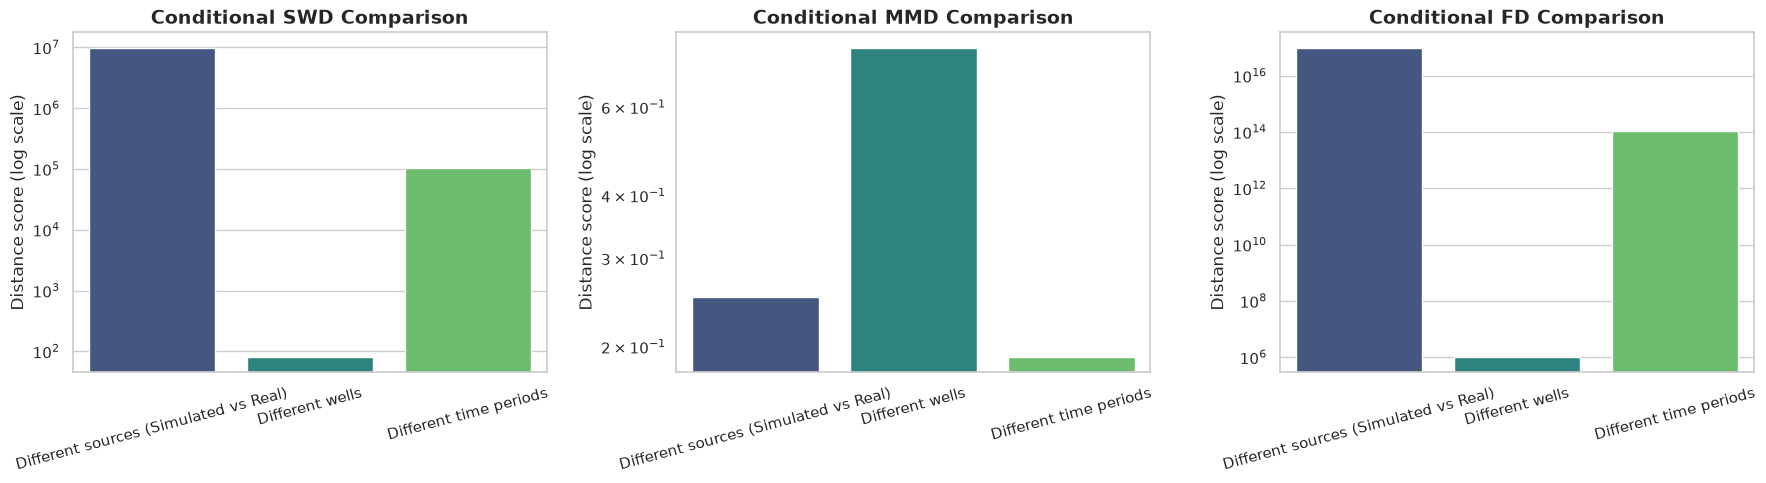

In [11]:
# Conditional distances for all three domain pairs
results = {
    'Different sources (Simulated vs Real)':
        pair_conditional_distances(source_sim, target_real, feature_names, SRC_CLASSES),
    'Different wells':
        pair_conditional_distances(source_wells, target_wells, feature_names, [0, 4]),
    'Different time periods':
        pair_conditional_distances(source_time, target_time, feature_names, [0, 4]),
}

# Summary table
results_df = pd.DataFrame(results).T
print("Conditional domain distance summary table")
display(results_df)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['Conditional SWD', 'Conditional MMD', 'Conditional FD']
for i, metric in enumerate(metrics):
    sns.barplot(
        x=results_df.index,
        y=results_df[metric],
        ax=axes[i],
        palette='viridis',
        hue=results_df.index,
        legend=False
    )
    axes[i].set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Distance score (log scale)')
    axes[i].set_xlabel('')
    axes[i].set_yscale('log')
    axes[i].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### Results

The bar charts above (log scale: the pairs span orders of magnitude) show the
conditional-distance hierarchy across the three domain pairs:

1. **SWD and FD rank the Sources pair as the largest gap by far** (SWD 9.9e6,
   FD 1.0e17), with Time second and Wells smallest. The simulator and the real
   wells genuinely differ in mean behavior: e.g. class 1 P-PDG is constant 0
   in simulated instances but reaches ~1.8e7 Pa in real ones.
2. **MMD contradicts this ranking**: the Wells pair has the largest MMD (0.79,
   driven by class 0 at 1.04) despite its tiny SWD/FD. The well shift is a
   covariance-shape change (consistent with the CORAL 0.070 of dom_dist), not
   a mean migration - and kernel-shape distance does not predict how hard the
   classifier finds the pair.
3. **The Time pair sits between**: SWD 1.0e5 and FD 1.1e14, driven by the
   class-0 2013 vs 2017 shift (dom_dist measured KS = 1.0 on four variables
   for that pair), yet its transfer penalty is the smallest (negative).

The transfer penalties (Sources 0.913, Wells 0.102, Time -0.097) align with
the mean-shift metrics only for the extreme Sources pair; the intra-real pairs
keep small penalties even where a metric reports a large gap. This is
consistent with the stage-1 finding that statistical distance does not simply
predict transferability.

## Transfer Learning:

To test how domain distance impacts transfer learning performance, we train a
non linear classifier (Random Forest) on the source domains and evaluate it
on the target domains.

For each of the three domain gaps, we will calculate the drop in the model's
F1-Score when moved from the Source to the unseen Target data.

In [12]:
def run_transfer_trials(source_df: pd.DataFrame, target_df: pd.DataFrame, features: list, n_trees: int = 100) -> dict:
    """
    Trains a Random Forest on the Source domain, evaluates a CV baseline on
    the Source, and evaluates transfer performance on the Target domain.

    Args:
        source_df (pd.DataFrame): Source domain DataFrame.
        target_df (pd.DataFrame): Target domain DataFrame.
        features (list): List of feature column names to use for training and evaluation.
        n_trees (int): Number of trees in the Random Forest.
    Returns:
        dict: Dictionary containing Baseline F1, Transfer F1, and Transfer Penalty.
    """
    X_src, y_src = source_df[features].values, source_df['Class'].values
    X_tgt, y_tgt = target_df[features].values, target_df['Class'].values

    rf = RandomForestClassifier(n_estimators=n_trees, random_state=42, n_jobs=-1)

    # Source baseline: stratified CV F1 (macro)
    min_class_count = min(np.bincount(y_src))
    n_splits = max(2, min(5, min_class_count))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    y_cv = cross_val_predict(rf, X_src, y_src, cv=skf)
    f1_baseline = f1_score(y_src, y_cv, average='macro')

    # Transfer: train on all source, predict on target
    rf.fit(X_src, y_src)
    f1_transfer = f1_score(y_tgt, rf.predict(X_tgt), average='macro')

    return {
        'Baseline F1': f1_baseline,
        'Transfer F1': f1_transfer,
        'Transfer Penalty': f1_baseline - f1_transfer,
    }

Domain distance vs. Transfer penalty


,Conditional SWD,Conditional MMD,Conditional FD,Baseline F1,Transfer F1,Transfer Penalty
Different sources (Simulated vs Real),9.929050e+06,0.251696,9.957779e+16,0.983987,0.070902,0.913085
Different wells,8.096734e+01,0.788593,1.022614e+06,0.982528,0.880438,0.102090
Different time periods,1.022037e+05,0.190884,1.073212e+14,0.878431,0.975442,-0.097010


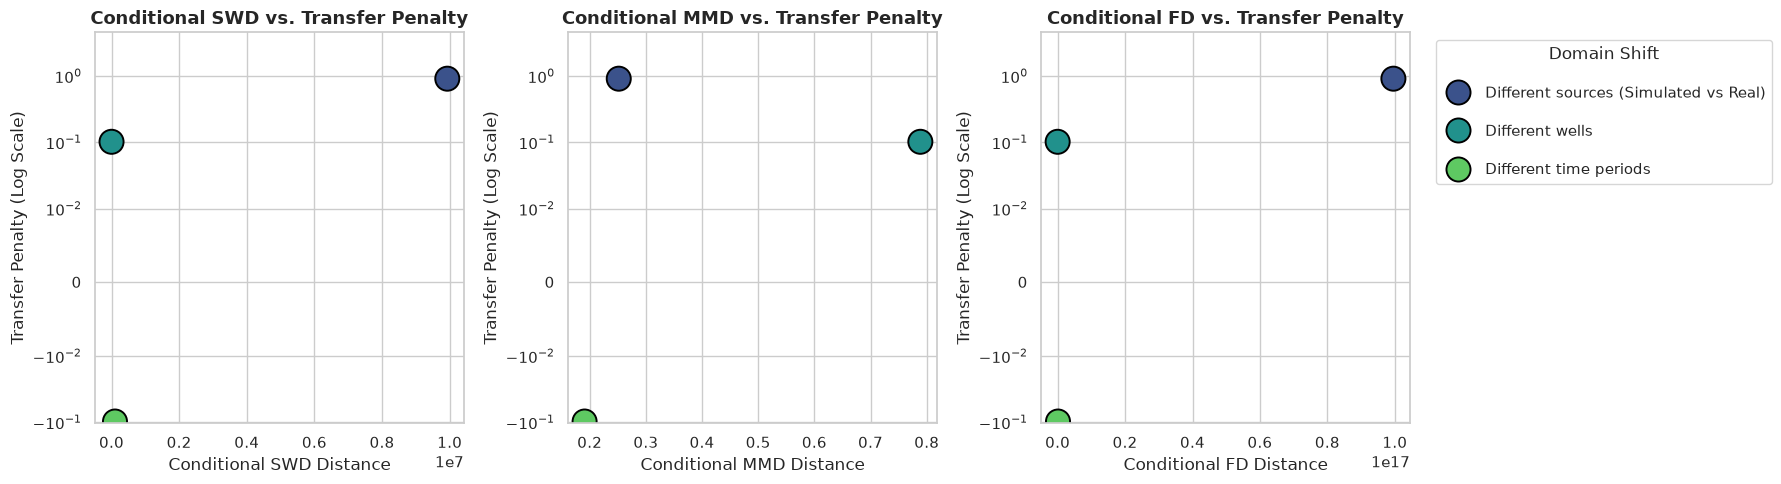

In [13]:
trials = {
    'Different sources (Simulated vs Real)':
        run_transfer_trials(source_sim, target_real, feature_names),
    'Different wells':
        run_transfer_trials(source_wells, target_wells, feature_names),
    'Different time periods':
        run_transfer_trials(source_time, target_time, feature_names),
}
final_results_df = pd.concat([results_df, pd.DataFrame(trials).T], axis=1)
print("Domain distance vs. Transfer penalty")
display(final_results_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['Conditional SWD', 'Conditional MMD', 'Conditional FD']
for i, metric in enumerate(metrics):
    sns.scatterplot(
        data=final_results_df,
        x=metric,
        y='Transfer Penalty',
        hue=final_results_df.index,
        palette='viridis',
        s=300,
        ax=axes[i],
        edgecolor='black'
    )

    axes[i].set_yscale('symlog', linthresh=0.01)

    # Include negative penalties: the Time pair's penalty is -0.097, so the
    # fixed bottom of -0.005 (from metropt3, where all penalties were positive)
    # would clip the Time dot out of the visible area.
    axes[i].set_ylim(bottom=final_results_df['Transfer Penalty'].min() - 0.005,
                     top=final_results_df['Transfer Penalty'].max() * 5)

    axes[i].set_title(f'{metric} vs. Transfer Penalty', fontweight='bold', fontsize=13)
    axes[i].set_ylabel('Transfer Penalty (Log Scale)')
    axes[i].set_xlabel(f'{metric} Distance')

    if i == 2:
        axes[i].legend(title='Domain Shift', bbox_to_anchor=(1.05, 1), loc='upper left', labelspacing=1.5)
    else:
        axes[i].get_legend().remove()
plt.tight_layout()

## Conclusion:

1. **Transfer Learning effectiveness depends on the source-target gap in the
   extreme case**: the Simulated to Real pair has by far the largest SWD and
   FD (9.9e6 / 1.0e17) and the only catastrophic penalty (0.913). The physics
   simulator generates instances far from the real event space, and the RF
   cannot bridge that gap.
2. **Intra-real pairs stay easy to transfer**: the Wells pair (penalty 0.102)
   and the Time pair (penalty -0.097, transfer F1 0.975 exceeds the source CV
   baseline 0.878) survive even where a metric reports a large gap - the
   class-0 time shift (SWD 1.0e5) is the second-largest distance in the table.
   The tiny 31-instance 2013 source makes its CV baseline pessimistic, and
   the 2014+2017 target is a large, clean population.
3. **The shift direction matters more than its magnitude**: mean migration
   (captured by SWD/FD) degrades the classifier, while covariance-shape
   changes (captured by MMD, e.g. Wells class 0 at 1.04) do not. A single
   scalar distance cannot rank transfer difficulty on this dataset - the
   metrics must be read together.
4. The Simulated to Real pair is the candidate for synthetic bridging: a
   generator that reduces its SWD/MMD/FD against the real rare classes should
   also reduce the 0.913 penalty. Stage 3 tests exactly this hypothesis with
   the CVAE on the shared fixed split.